# 4.5.权重衰减

前一节我们描述了过拟合的问题，本节我们将介绍一些正则化模型的技术。我们总是可以通过去收集更多的训练数据来缓解过拟合。但这可能成本很高，耗时颇多，或者完全超出我们的控制，因而在短期内不可能做到。假设我们已经拥有尽可能多的高质量数据，我们便可以将重点放在正则化技术上。

回想一下，在多项式回归的例子（ [4.4节](./04.04_underfit_overfit.ipynb)）中，我们可以通过调整拟合多项式的阶数来限制模型的容量。实际上，限制特征的数量是缓解过拟合的一种常用技术。然而，简单地丢弃特征对这项工作来说可能过于生硬。我们继续思考多项式回归的例子，考虑高维输入可能发生的情况。多项式对多变量数据的自然扩展称为*单项式*（monomials），也可以说是变量幂的乘积。单项式的阶数是幂的和。例如，$x_1^2 x_2$和$x_3 x_5^2$都是3次单项式。

注意，随着阶数$d$的增长，带有阶数$d$的项数迅速增加。 给定$k$个变量，阶数为$d$的项的个数为${k - 1 + d} \choose {k - 1}$，即$C^{k-1}_{k-1+d} = \frac{(k-1+d)!}{(d)!(k-1)!}$。因此即使是阶数上的微小变化，比如从$2$到$3$，也会显著增加我们模型的复杂性。仅仅通过简单的限制特征数量（在多项式回归中体现为限制阶数），可能仍然使模型在过简单和过复杂中徘徊，我们需要一个更细粒度的工具来调整函数的复杂性，使其达到一个合适的平衡位置。


---
## 环境配置


In [1]:
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('torch_npu.env').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor with interal format")
import pypto
import pypto.pypto_impl as impl
import torch
import torch_npu
import matplotlib.pyplot as plt

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
impl.DeviceInit()

from torch import nn
# 从共享算子库导入 NPU 算子（定义见 ./src/pypto_ops.py）
from src.pypto_ops import PyPTOLinear, PyPTOMatmul, mse_loss

from src.utils import plot

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l
    </pre>
  </div>
</details>


---


## 4.5.1.范数与权重衰减

在 [2.4节](../02_pypto_preliminaries/)中，我们已经描述了$L_2$范数和$L_1$范数，它们是更为一般的$L_p$范数的特殊情况。

在训练参数化机器学习模型时，*权重衰减*（weight decay）是最广泛使用的正则化的技术之一，它通常也被称为$L_2$*正则化*。这项技术通过函数与零的距离来衡量函数的复杂度，因为在所有函数$f$中，函数$f = 0$（所有输入都得到值$0$）在某种意义上是最简单的。但是我们应该如何精确地测量一个函数和零之间的距离呢？没有一个正确的答案。事实上，函数分析和巴拿赫空间理论的研究，都在致力于回答这个问题。

一种简单的方法是通过线性函数$f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x}$中的权重向量的某个范数来度量其复杂性，例如$\| \mathbf{w} \|^2$。要保证权重向量比较小，最常用方法是将其范数作为惩罚项加到最小化损失的问题中。将原来的训练目标*最小化训练标签上的预测损失*，调整为*最小化预测损失和惩罚项之和*。现在，如果我们的权重向量增长的太大，我们的学习算法可能会更集中于最小化权重范数$\| \mathbf{w} \|^2$。这正是我们想要的。让我们回顾一下 [3.2节](../03_pypto_linear_networks/)中的线性回归例子。我们的损失由下式给出：

$$L(\mathbf{w}, b) = \frac{1}{n}\sum_{i=1}^n \frac{1}{2}\left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2.$$

回想一下，$\mathbf{x}^{(i)}$是样本$i$的特征，$y^{(i)}$是样本$i$的标签，$(\mathbf{w}, b)$是权重和偏置参数。为了惩罚权重向量的大小，我们必须以某种方式在损失函数中添加$\| \mathbf{w} \|^2$，但是模型应该如何平衡这个新的额外惩罚的损失？实际上，我们通过*正则化常数*$\lambda$来描述这种权衡，这是一个非负超参数，我们使用验证数据拟合：
$$L(\mathbf{w}, b) + \frac{\lambda}{2} \|\mathbf{w}\|^2,$$
对于$\lambda = 0$，我们恢复了原来的损失函数。对于$\lambda > 0$，我们限制$\| \mathbf{w} \|$的大小。这里我们仍然除以$2$：当我们取一个二次函数的导数时，$2$和$1/2$会抵消，以确保更新表达式看起来既漂亮又简单。为什么在这里我们使用平方范数而不是标准范数（即欧几里得距离）？我们这样做是为了便于计算。通过平方$L_2$范数，我们去掉平方根，留下权重向量每个分量的平方和。这使得惩罚的导数很容易计算：导数的和等于和的导数。

此外，为什么我们首先使用$L_2$范数，而不是$L_1$范数。事实上，这个选择在整个统计领域中都是有效的和受欢迎的。$L_2$正则化线性模型构成经典的*岭回归*（ridge regression）算法，$L_1$正则化线性回归是统计学中类似的基本模型，通常被称为*套索回归*（lasso regression）。使用$L_2$范数的一个原因是它对权重向量的大分量施加了巨大的惩罚。这使得我们的学习算法偏向于在大量特征上均匀分布权重的模型。在实践中，这可能使它们对单个变量中的观测误差更为稳定。相比之下，$L_1$惩罚会导致模型将权重集中在一小部分特征上，而将其他权重清除为零。这称为*特征选择*（feature selection），这可能是其他场景下需要的。

使用与 上述更新公式中的相同符号，$L_2$正则化回归的小批量随机梯度下降更新如下式：

$$
\begin{aligned}
\mathbf{w} & \leftarrow \left(1- \eta\lambda \right) \mathbf{w} - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \mathbf{x}^{(i)} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right).
\end{aligned}
$$

根据之前章节所讲的，我们根据估计值与观测值之间的差异来更新$\mathbf{w}$。然而，我们同时也在试图将$\mathbf{w}$的大小缩小到零。这就是为什么这种方法有时被称为*权重衰减*。我们仅考虑惩罚项，优化算法在训练的每一步*衰减*权重。与特征选择相比，权重衰减为我们提供了一种连续的机制来调整函数的复杂度。较小的$\lambda$值对应较少约束的$\mathbf{w}$，而较大的$\lambda$值对$\mathbf{w}$的约束更大。

是否对相应的偏置$b^2$进行惩罚在不同的实践中会有所不同，在神经网络的不同层中也会有所不同。通常，网络输出层的偏置项不会被正则化。
## 4.5.2.高维线性回归

我们通过一个简单的例子来演示权重衰减。


首先，我们**像以前一样生成一些数据**，生成公式如下：
$$y = 0.05 + \sum_{i = 1}^d 0.01 x_i + \epsilon \text{ where }
\epsilon \sim \mathcal{N}(0, 0.01^2).$$
我们选择标签是关于输入的线性函数。标签同时被均值为0，标准差为0.01高斯噪声破坏。为了使过拟合的效果更加明显，我们可以将问题的维数增加到$d = 200$，并使用一个只包含20个样本的小训练集。


In [2]:
# 定义 synthetic_data（移植自 03.03 节）
def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)), device=device)
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape, device=device)
    return X, y.reshape((-1, 1))

# 定义 load_array（移植自 03.03 节）
def load_array(data_arrays, batch_size, is_train=True):
    """构造一个 PyTorch 数据迭代器"""
    from torch.utils import data
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

# 维数增加到 d=200，训练集只含 20 个样本，便于放大过拟合效果
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1), device=device) * 0.01, 0.05
train_data = synthetic_data(true_w, true_b, n_train)
train_iter = load_array(train_data, batch_size)
test_data = synthetic_data(true_w, true_b, n_test)
test_iter = load_array(test_data, batch_size, is_train=False)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)
    </pre>
  </div>
</details>

## 4.5.3.从零开始实现

下面我们将从头开始实现权重衰减，只需将$L_2$的平方惩罚添加到原始目标函数中。
### 4.5.3.1.初始化模型参数

首先，我们将定义一个函数来随机初始化模型参数。


In [3]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True, device=device)
    b = torch.zeros(1, requires_grad=True, device=device)
    return [w, b]

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]
    </pre>
  </div>
</details>

### 4.5.3.2.定义$L_2$范数惩罚

实现这一惩罚最方便的方法是对所有项求平方后并将它们求和。


In [4]:
# 定义 L2 范数惩罚：对所有项求平方后求和（标量 reduction，用 torch 原生操作即可）
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

# 定义 sgd（移植自 03.03 节，内部 /batch_size 归一）
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

# 定义 evaluate_loss（与 04.04 节相同）
def evaluate_loss(net, data_iter, loss):
    metric = [0.0, 0]  # 损失总和, 样本数量
    with torch.no_grad():
        for X, y in data_iter:
            out = net(X)
            y = y.reshape(out.shape)
            l = loss(out, y, reduction='none')
            metric[0] += l.sum().item()
            metric[1] += l.numel()
    return metric[0] / metric[1]

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2
    </pre>
  </div>
</details>

### 4.5.3.3.定义训练代码实现

下面的代码将模型拟合训练数据集，并在测试数据集上进行评估。

In [5]:
def train(lambd):
    w, b = init_params()
    net = lambda X: PyPTOMatmul.apply(X, w) + b
    num_epochs, lr = 100, 0.003

    train_losses, test_losses = [], []
    for epoch in range(num_epochs):
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            # 数据损失：reduction='sum' 配合 sgd 的 /batch_size = 一次 mean（仅数据损失等价）
            # 惩罚项：d2l 借广播 + .sum() 把标量惩罚放大 batch_size 倍以抵消 sgd 的 /batch_size，
            #         使有效衰减系数为 lambd。这里把惩罚加在已 sum 的标量之后，必须显式乘
            #         batch_size 复现该效果，否则有效衰减会被弱化为 lambd/batch_size。
            l = mse_loss(net(X), y, reduction='sum') + batch_size * lambd * l2_penalty(w)
            l.backward()
            sgd([w, b], lr, batch_size)  # 手写 SGD，内部 /batch_size 归一
        if (epoch + 1) % 5 == 0:
            train_losses.append((epoch + 1, evaluate_loss(net, train_iter, mse_loss)))
            test_losses.append((epoch + 1, evaluate_loss(net, test_iter, mse_loss)))

    epochs_t, l_t = zip(*train_losses)
    epochs_e, l_e = zip(*test_losses)
    plot(torch.tensor(epochs_t), [l_t, l_e], 'epoch', 'loss',
         legend=['train', 'test'], xlim=[1, num_epochs], yscale='log',
         figsize=(6, 3))
    print('w 的 L2 范数是：', torch.norm(w).item())

<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <ul style="margin: 0; padding-left: 20px;">
      <li style="margin: 0 0 8px 0;"><code>net</code> 用 <code>PyPTOMatmul.apply(X, w) + b</code>（NPU matmul + torch 标量广播加），保持全链路 pypto 化，与 04.01~04.03 一致。bias 是标量加法，无需 pypto kernel。</li>
      <li style="margin: 0 0 8px 0;"><strong>L2 惩罚为何不写 pypto kernel</strong>：<code>l2_penalty(w)</code> 是「标量对向量求平方和」的 reduction 操作，torch 在 NPU 上的 <code>sum</code> 已足够高效，写 pypto kernel 反而增加编译开销。这与 04.02 中 matmul/bias_add 写 kernel 的动机不同——那些是 batch 级别的大规模运算，pypto 的 tile 切分才有收益。</li>
      <li style="margin: 0 0 8px 0;"><strong>归约口径（须分两项各自对齐 d2l）</strong>：<br/>① <strong>数据损失</strong>：<code>reduction='sum'</code> 配合 <code>sgd</code> 的 <code>/batch_size</code> = 一次 mean，与 d2l（逐元素 <code>squared_loss</code> + <code>l.sum().backward()</code> + <code>sgd /batch_size</code>）的数据损失项等价。<br/>② <strong>惩罚项</strong>：d2l 把标量 <code>lambd*l2_penalty(w)</code> 加在<strong>逐元素</strong>数据损失上，借广播变成长度 <code>batch_size</code> 的向量，<code>.sum()</code> 时被放大 <code>batch_size</code> 倍，恰好抵消 <code>sgd</code> 的 <code>/batch_size</code>，有效衰减系数 = <code>lambd</code>。本实现把惩罚加在<strong>已 sum 的标量</strong>之后（未经广播放大），因此必须<strong>显式乘 <code>batch_size</code></strong> 才能复现同样的有效衰减系数；否则有效衰减会被弱化为 <code>lambd/batch_size</code>，使<code>w</code> 的 L2 范数随 <code>lambd</code> 增大而显著减小的核心演示明显变弱。</li>
    </ul>
  </div>
</details>
<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了L2范数惩罚项，            # 广播机制使l2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())
    </pre>
  </div>
</details>

### 4.5.3.4.忽略正则化直接训练

我们现在用`lambd = 0`禁用权重衰减后运行这个代码。注意，这里训练误差有了减少，但测试误差没有减少，这意味着出现了严重的过拟合。


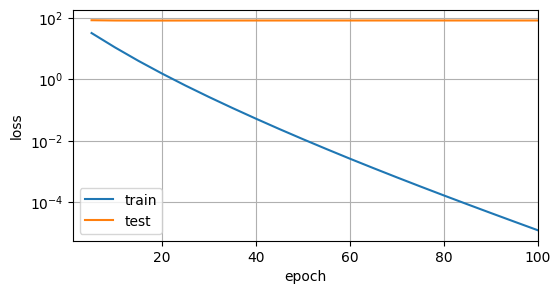

w 的 L2 范数是： 13.853791236877441


In [6]:
# lambd=0 禁用权重衰减：训练误差下降但测试误差不降，严重过拟合
train(lambd=0)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
train(lambd=0)
    </pre>
  </div>
</details>

### 4.5.3.5.使用权重衰减

下面，我们使用权重衰减来运行代码。注意，在这里训练误差增大，但测试误差减小。这正是我们期望从正则化中得到的效果。


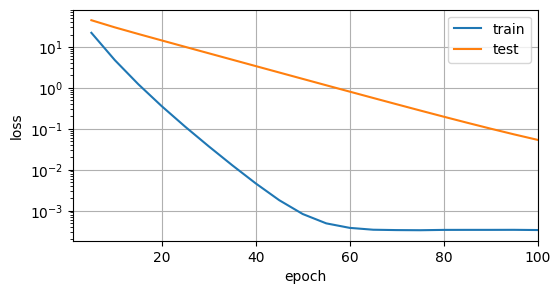

w 的 L2 范数是： 0.35409173369407654


In [7]:
# lambd=3 使用权重衰减：训练误差略增，但测试误差下降——这正是正则化的效果
train(lambd=3)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
train(lambd=3)
    </pre>
  </div>
</details>

## 4.5.4.简洁实现

由于权重衰减在神经网络优化中很常用，深度学习框架为了便于我们使用权重衰减，将权重衰减集成到优化算法中，以便与任何损失函数结合使用。此外，这种集成还有计算上的好处，允许在不增加任何额外的计算开销的情况下向算法中添加权重衰减。由于更新的权重衰减部分仅依赖于每个参数的当前值，因此优化器必须至少接触每个参数一次。


在下面的代码中，我们在实例化优化器时直接通过`weight_decay`指定weight decay超参数。默认情况下，PyTorch同时衰减权重和偏移。这里我们只为权重设置了`weight_decay`，所以偏置参数$b$不会衰减。


简洁实现中，权重衰减由 `torch.optim.SGD(weight_decay=wd)` 在优化器层完成——它在 `SGD.step()` 中对参数额外施加衰减，与 forward/backward 的 NPU kernel **正交**，无需任何 pypto 改动。全部 NPU 计算通过 `PyPTOLinear` 完成，正则化交给 PyTorch 优化器接管。

**关于损失数值（1/2 因子）**：`mse_loss` 含 1/2 因子（`(ŷ-y)²/2`，对齐 d2l `squared_loss`），而 d2l 本节简洁实现用的是**不含 1/2** 的 `nn.MSELoss`。因此报出的 loss 数值为 d2l 的 **0.5 倍**、有效学习率相当于减半；又因 `weight_decay` 作用在 0.5× 的数据损失梯度之上，其相对正则强度与 d2l 不完全同步。**定性**结论（正则化降低测试误差）不受影响。

In [8]:
def train_concise(wd):
    net = nn.Sequential(PyPTOLinear(num_inputs, 1)).to(device)
    for param in net.parameters():
        param.data.normal_()
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减：只为 weight 设置 weight_decay
    trainer = torch.optim.SGD([
        {"params": net[0].weight, "weight_decay": wd},
        {"params": net[0].bias}
    ], lr=lr)

    train_losses, test_losses = [], []
    for epoch in range(num_epochs):
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            trainer.zero_grad()
            # reduction='mean'：torch.optim.SGD 不做额外归一，归一化在 loss 完成
            l = mse_loss(net(X), y, reduction='mean')
            l.backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            train_losses.append((epoch + 1, evaluate_loss(net, train_iter, mse_loss)))
            test_losses.append((epoch + 1, evaluate_loss(net, test_iter, mse_loss)))

    epochs_t, l_t = zip(*train_losses)
    epochs_e, l_e = zip(*test_losses)
    plot(torch.tensor(epochs_t), [l_t, l_e], 'epoch', 'loss',
         legend=['train', 'test'], xlim=[1, num_epochs], yscale='log',
         figsize=(6, 3))
    print('w 的 L2 范数：', net[0].weight.norm().item())

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay': wd},
        {"params":net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                         (d2l.evaluate_loss(net, train_iter, loss),
                          d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数：', net[0].weight.norm().item())
    </pre>
  </div>
</details>

**这些图看起来和我们从零开始实现权重衰减时的图相同**。然而，它们运行得更快，更容易实现。对于更复杂的问题，这一好处将变得更加明显。


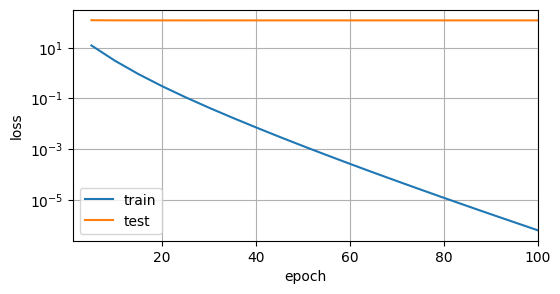

w 的 L2 范数： 13.746268272399902


In [9]:
train_concise(0)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
train_concise(0)
    </pre>
  </div>
</details>

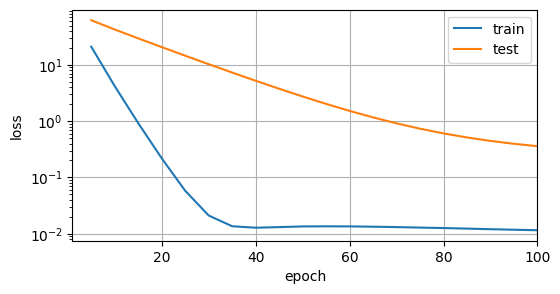

w 的 L2 范数： 0.3867485225200653


In [10]:
train_concise(3)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
train_concise(3)
    </pre>
  </div>
</details>

---

到目前为止，我们只接触到一个简单线性函数的概念。此外，由什么构成一个简单的非线性函数可能是一个更复杂的问题。例如，[再生核希尔伯特空间（RKHS）](https://en.wikipedia.org/wiki/Reproducing_kernel_Hilbert_space)允许在非线性环境中应用为线性函数引入的工具。不幸的是，基于RKHS的算法往往难以应用到大型、高维的数据。在这本书中，我们将默认使用简单的启发式方法，即在深层网络的所有层上应用权重衰减。
## 4.5.5.小结

* 正则化是处理过拟合的常用方法：在训练集的损失函数中加入惩罚项，以降低学习到的模型的复杂度。
* 保持模型简单的一个特别的选择是使用$L_2$惩罚的权重衰减。这会导致学习算法更新步骤中的权重衰减。
* 权重衰减功能在深度学习框架的优化器中提供。
* 在同一训练代码实现中，不同的参数集可以有不同的更新行为。
## 4.5.6.练习

1. 在本节的估计问题中使用$\lambda$的值进行实验。绘制训练和测试精度关于$\lambda$的函数。观察到了什么？
1. 使用验证集来找到最佳值$\lambda$。它真的是最优值吗？这有关系吗？
1. 如果我们使用$\sum_i |w_i|$作为我们选择的惩罚（$L_1$正则化），那么更新方程会是什么样子？
1. 我们知道$\|\mathbf{w}\|^2 = \mathbf{w}^\top \mathbf{w}$。能找到类似的矩阵方程吗（见 [2.4节](../02_pypto_preliminaries/) 中的Frobenius范数）？
1. 回顾训练误差和泛化误差之间的关系。除了权重衰减、增加训练数据、使用适当复杂度的模型之外，还能想出其他什么方法来处理过拟合？
1. 在贝叶斯统计中，我们使用先验和似然的乘积，通过公式$P(w \mid x) \propto P(x \mid w) P(w)$得到后验。如何得到带正则化的$P(w)$？

参考答案详见 [answers/04.05_reference_answer](./answers/04.05_reference_answer.ipynb)。


### 参考答案（PyPTO）


In [11]:
!cat answers/txt/04.05_reference_answer_pypto.txt

### 参考答案（PyTorch）


In [12]:
!cat answers/txt/04.05_reference_answer_pytorch.txt